# **Student Perfomance Prediction and Analytics System**

##**1. Importing Libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

##**2.Data Importing**

In [2]:
student = pd.read_csv("/content/student_performance_dataset.csv")

In [3]:
student

,Student_ID,Gender,Age,Attendance,Study_Hours,Internet,Parent_Education,Family_Income,Sleep_Hours,Assignments,Previous_Grade,Final_Exam,Performance_Level
0,STU016132,Female,20,98.2,3.9,Yes,Bachelor Degree,46231.0,8.6,80.0,57.9,74.4,Good
1,STU022503,Male,18,87.2,3.9,No,Primary,25802.0,6.5,67.0,64.3,70.8,Good
2,STU009282,Other,19,88.6,5.1,Yes,Primary,65136.0,8.5,52.0,90.8,68.7,Average
3,STU020514,Male,18,100.0,3.9,Yes,Bachelor,"₹ 17,844",5.5,73.0,86.5,84.6,Good
4,STU012396,Male,19,79.8,4.4,No,Bachelor's,52482.0,6.3,85.0,58.6,67.4,Average
...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,STU004024,Female,20,98.4,6.1,Y,NaN,"19,714",7.7,64.0,94.2,86.1,Excellent
29996,STU007260,Male,21,71.1,1.8,Yes,High School,49569.0,NaN,70.0,50.9,60.9,Average
29997,STU021585,Male,18,92.7,7.5,Yes,Bachelor,₹17472,6.0,100.0,59.9,83.3,Good
29998,STU003776,Female,18,86.8,5.9,Yes,High School,23272.0,6.5,91.0,61.2,74.7,Good


In [4]:
student.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Student_ID         30000 non-null  object 
 1   Gender             30000 non-null  object 
 2   Age                30000 non-null  int64  
 3   Attendance         28255 non-null  object 
 4   Study_Hours        28498 non-null  float64
 5   Internet           28884 non-null  object 
 6   Parent_Education   28529 non-null  object 
 7   Family_Income      28216 non-null  object 
 8   Sleep_Hours        28656 non-null  float64
 9   Assignments        28256 non-null  float64
 10  Previous_Grade     28756 non-null  float64
 11  Final_Exam         30000 non-null  float64
 12  Performance_Level  30000 non-null  object 
dtypes: float64(5), int64(1), object(7)
memory usage: 3.0+ MB


In [5]:
student.isnull().sum()

,0
Student_ID,0
Gender,0
Age,0
Attendance,1745
Study_Hours,1502
Internet,1116
Parent_Education,1471
Family_Income,1784
Sleep_Hours,1344
Assignments,1744


In [6]:
student.describe()

,Age,Study_Hours,Sleep_Hours,Assignments,Previous_Grade,Final_Exam
count,30000.000000,28498.000000,28656.000000,28256.000000,28756.000000,30000.000000
mean,19.329600,5.035687,6.803884,78.921149,64.965795,68.010870
std,1.214446,1.864869,1.007744,13.429979,14.732915,10.805984
min,15.000000,-2.000000,3.000000,16.000000,30.000000,25.100000
25%,18.000000,3.800000,6.100000,70.000000,54.900000,61.300000
50%,19.000000,5.000000,6.800000,79.000000,65.000000,68.200000
75%,20.000000,6.300000,7.500000,89.000000,75.100000,75.100000
max,30.000000,12.000000,15.000000,120.000000,100.000000,100.000000


In [7]:
# Count duplicate rows
duplicate_count = student.duplicated().sum()

print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 0


In [8]:
student["Gender"].unique()

array(['Female', 'Male', 'Other', 'Male ', 'MALE', 'Female  ', 'Female ',
       'male', 'FEMALE', '  Male', ' Male  ', '  Other', ' Female',
       'female', ' Male', 'Male  ', 'other', '  MALE', 'Female   ',
       '  female', ' Female  ', 'female  ', 'OTHER', '  Female',
       'Male   ', 'MALE  ', '  Male ', 'Other  ', '   Female', '   Male',
       'male  ', '  FEMALE', 'FEMALE  ', '  male', '  Female ', '  OTHER',
       'OTHER  ', 'other  ', '  other'], dtype=object)

In [9]:
# Remove leading/trailing spaces and standardize case
student["Gender"] = (
    student["Gender"]
    .str.strip()
    .str.title()
)

In [10]:
student["Gender"].unique()

array(['Female', 'Male', 'Other'], dtype=object)

In [11]:
mode_gender = student["Gender"].mode()[0]
print(mode_gender)

Female


In [12]:
mode_internet = student["Internet"].mode()[0]
print(mode_internet)

Yes


In [13]:
student["Internet"].value_counts()

,count
Internet,
Yes,17591
No,2401
yes,1432
YES,1427
Y,1404
Yes,1332
Yes,740
Yes,706
Unknown,302


In [14]:
student["Internet"] = student["Internet"].replace("Unknown", "Yes")

In [15]:
student["Gender"].value_counts()

,count
Gender,
Female,14773
Male,14623
Other,604


In [16]:
student["Gender"] = student["Gender"].replace("Other", "Female")

In [17]:
student["Age"].describe()

,Age
count,30000.000000
mean,19.329600
std,1.214446
min,15.000000
25%,18.000000
50%,19.000000
75%,20.000000
max,30.000000


In [18]:
student["Age"].unique()

array([20, 18, 19, 21, 16, 22, 17, 23, 15, 30])

In [19]:
invalid_age = student[(student["Age"] < 15) | (student["Age"] > 23)]

print(f"Number of invalid age records: {len(invalid_age)}")
invalid_age

Number of invalid age records: 9


,Student_ID,Gender,Age,Attendance,Study_Hours,Internet,Parent_Education,Family_Income,Sleep_Hours,Assignments,Previous_Grade,Final_Exam,Performance_Level
8603,STU010769,Female,30,100.0,3.4,N,High-School,38609.0,6.6,77.0,37.9,61.0,Average
14225,STU009884,Male,30,81.3,4.7,Yes,Bachelor,25627.0,5.6,94.0,78.8,70.3,Good
14653,STU007527,Female,30,73.5,1.5,Yes,Master,98054.0,8.9,56.0,NaN,77.7,Good
16339,STU023557,Female,30,96.1,7.0,No,High School,30870.0,8.3,94.0,66.8,72.9,Good
16640,STU007029,Female,30,78.9,NaN,Yes,no school,54763.0,6.8,84.0,63.7,72.2,Good
23138,STU015127,Female,30,75.3,8.3,Y,High School,104549.0,7.0,67.0,82.0,95.3,Excellent
26951,STU001325,Male,30,37.3,2.9,Yes,Primary,35348.0,7.2,68.0,72.2,61.7,Average
28710,STU003721,Female,30,71.4,6.6,Yes,Diploma,18141.0,NaN,76.0,71.4,78.1,Good
29467,STU028578,Female,30,70.1,7.0,Yes,high school,35284.0,6.0,99.0,56.3,70.5,Good


In [20]:
((student["Age"] < 15) | (student["Age"] > 23)).sum()

np.int64(9)

In [21]:
student.loc[(student["Age"] < 15) | (student["Age"] > 23), "Age"].value_counts().sort_index()

,count
Age,
30,9


In [22]:
# Calculate the median of valid ages
median_age = student.loc[student["Age"].between(15, 22), "Age"].median()

# Replace invalid age (30) with the median
student.loc[student["Age"] == 30, "Age"] = median_age

In [23]:
# Check again for invalid ages
student[(student["Age"] < 15) | (student["Age"] > 23)]

,Student_ID,Gender,Age,Attendance,Study_Hours,Internet,Parent_Education,Family_Income,Sleep_Hours,Assignments,Previous_Grade,Final_Exam,Performance_Level


In [24]:
student["Attendance"].dtype

dtype('O')

In [25]:
student["Attendance"].isnull().sum()

np.int64(1745)

In [26]:
student["Attendance"].sample(20)

,Attendance
5094,60.2
25699,75.6
16535,74.7
10937,78.4
10167,NaN
25020,75.9
7432,62.1
11998,87.3
7139,98.8
28421,72.8


In [27]:
student["Attendance"] = pd.to_numeric(student["Attendance"], errors="coerce")

In [28]:
mean_attendance = student["Attendance"].mean()

In [29]:
mean_attendance

np.float64(77.22603224834236)

In [30]:
print(student["Attendance"].isnull().sum())
print(student["Attendance"].dtype)

3456
float64


In [31]:
mean_attendance = student["Attendance"].mean()

student["Attendance"] = student["Attendance"].fillna(mean_attendance)

In [32]:
student["Attendance"].describe()

,Attendance
count,30000.000000
mean,77.226032
std,13.622870
min,-5.000000
25%,69.000000
50%,77.226032
75%,86.600000
max,105.000000


In [33]:
invalid_attendance = student[(student["Attendance"] < 0) | (student["Attendance"] > 100)]

print(f"Number of invalid attendance records: {len(invalid_attendance)}")
invalid_attendance

Number of invalid attendance records: 20


,Student_ID,Gender,Age,Attendance,Study_Hours,Internet,Parent_Education,Family_Income,Sleep_Hours,Assignments,Previous_Grade,Final_Exam,Performance_Level
652,STU011919,Female,18,105.0,5.4,Yes,bachelor,32497.0,7.8,85.0,62.6,68.3,Average
3520,STU021141,Male,19,-5.0,1.7,yes,Bachelors,28563.0,6.9,69.0,59.1,69.4,Average
5576,STU028388,Male,19,105.0,3.9,Yes,Diploma,42779.0,6.4,62.0,79.4,71.6,Good
5768,STU015396,Female,18,-5.0,4.6,Yes,High-School,23866.0,4.0,82.0,59.7,64.0,Average
7147,STU002153,Female,19,-5.0,7.1,Yes,High School,NaN,6.9,77.0,62.3,76.6,Good
10700,STU022740,Male,19,105.0,5.3,Yes,High School,25920.0,7.9,69.0,87.3,84.8,Good
13258,STU024158,Male,18,105.0,3.5,No,Primary,52150.0,5.7,76.0,75.6,70.0,Good
14154,STU023223,Male,19,105.0,6.0,Yes,Primary,31904.0,6.0,64.0,69.0,67.0,Average
15648,STU014106,Male,19,-5.0,4.5,Yes,Bachelor,36901.0,6.8,74.0,37.3,47.8,Poor
16866,STU012210,Male,19,-5.0,3.6,Yes,Unknown,13679.0,7.5,99.0,71.0,74.1,Good


In [34]:
student.loc[
    (student["Attendance"] < 0) | (student["Attendance"] > 100),
    "Attendance"
].value_counts().sort_index()

,count
Attendance,
-5.0,10
105.0,10


In [35]:
mean_attendance = student.loc[
    student["Attendance"].between(0, 100),
    "Attendance"
].mean()

student.loc[
    (student["Attendance"] < 0) | (student["Attendance"] > 100),
    "Attendance"
] = mean_attendance

In [36]:
student["Study_Hours"].dtype

dtype('float64')

In [37]:
student.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Student_ID         30000 non-null  object 
 1   Gender             30000 non-null  object 
 2   Age                30000 non-null  int64  
 3   Attendance         30000 non-null  float64
 4   Study_Hours        28498 non-null  float64
 5   Internet           28884 non-null  object 
 6   Parent_Education   28529 non-null  object 
 7   Family_Income      28216 non-null  object 
 8   Sleep_Hours        28656 non-null  float64
 9   Assignments        28256 non-null  float64
 10  Previous_Grade     28756 non-null  float64
 11  Final_Exam         30000 non-null  float64
 12  Performance_Level  30000 non-null  object 
dtypes: float64(6), int64(1), object(6)
memory usage: 3.0+ MB


In [38]:
student["Study_Hours"].isnull().sum()

np.int64(1502)

In [39]:
student["Study_Hours"].describe()

,Study_Hours
count,28498.000000
mean,5.035687
std,1.864869
min,-2.000000
25%,3.800000
50%,5.000000
75%,6.300000
max,12.000000


### Cleaning 'Study_Hours'

In [40]:
# Identify and count invalid 'Study_Hours' (negative values)
invalid_study_hours_count = student[student['Study_Hours'] < 0].shape[0]
print(f"Number of invalid 'Study_Hours' records (negative values): {invalid_study_hours_count}")

# Replace invalid 'Study_Hours' (negative values) with the median of valid study hours
median_study_hours = student.loc[student['Study_Hours'] >= 0, 'Study_Hours'].median()
student.loc[student['Study_Hours'] < 0, 'Study_Hours'] = median_study_hours

# Fill missing 'Study_Hours' with the mean of valid study hours
mean_study_hours = student['Study_Hours'].mean()
student['Study_Hours'] = student['Study_Hours'].fillna(mean_study_hours)

print("\n'Study_Hours' after cleaning:")
display(student['Study_Hours'].describe())

Number of invalid 'Study_Hours' records (negative values): 10

'Study_Hours' after cleaning:


,Study_Hours
count,30000.000000
mean,5.038143
std,1.813038
min,0.500000
25%,3.900000
50%,5.038143
75%,6.200000
max,12.000000


### Cleaning 'Internet'

In [41]:
# Check unique values for 'Internet'
print("Original unique values for 'Internet':")
print(student["Internet"].unique())

# Standardize 'Internet' values
student["Internet"] = student["Internet"].str.strip().str.title().replace({'Y': 'Yes', 'N': 'No'})

# Fill missing 'Internet' values with the mode
mode_internet = student["Internet"].mode()[0]
student["Internet"] = student["Internet"].fillna(mode_internet)

print("\nCleaned unique values for 'Internet':")
print(student["Internet"].unique())
print("\n'Internet' value counts after cleaning:")
print(student["Internet"].value_counts())

Original unique values for 'Internet':
['Yes' 'No' ' No' 'Yes ' nan 'Y' 'yes' 'YES' 'No  ' 'N' 'Yes  ' 'no  '
 'NO' 'yes  ' '  Yes' 'no' 'Y  ' 'Yes   ' '  Y' '  yes' '  Yes ' '  No'
 '  N' 'N  ' 'YES  ' '  YES' 'NO  ' '  no' '   No' ' No  ' '  NO']

Cleaned unique values for 'Internet':
['Yes' 'No']

'Internet' value counts after cleaning:
Internet
Yes    26527
No      3473
Name: count, dtype: int64


### Cleaning 'Parent_Education'

In [42]:
# Check unique values for 'Parent_Education'
print("Original unique values for 'Parent_Education':")
print(student["Parent_Education"].unique())

# Standardize 'Parent_Education' values
student["Parent_Education"] = student["Parent_Education"].str.strip().str.title()
student["Parent_Education"] = student["Parent_Education"].replace({
    "Bachelors": "Bachelor Degree",
    "Bachelor's": "Bachelor Degree",
    "Highschool": "High School",
    "High-School": "High School",
    "Masters": "Master Degree",
    "Doctorate": "Doctorate Degree",
    "No School": "No Formal Education",
    "Unknown": "No Formal Education"
})

# Fill missing 'Parent_Education' values with the mode
mode_parent_education = student["Parent_Education"].mode()[0]
student["Parent_Education"] = student["Parent_Education"].fillna(mode_parent_education)

print("\nCleaned unique values for 'Parent_Education':")
print(student["Parent_Education"].unique())
print("\n'Parent_Education' value counts after cleaning:")
print(student["Parent_Education"].value_counts())

Original unique values for 'Parent_Education':
['Bachelor Degree' 'Primary' 'Bachelor' "Bachelor's" '  High School' 'PhD'
 'High School' 'Master Degree' 'high school' 'Bachelors' 'bachelor'
 'primary' 'Master' 'Masters' 'Diploma' 'High School  ' 'PRIMARY'
 'diploma' 'HighSchool' 'High-School' 'No School' '  Bachelor'
 'Diploma Course' nan 'Bachelors  ' 'Ph.D' 'High  School' '  PhD' 'PhD  '
 'HIGH SCHOOL' 'NO SCHOOL' "Master's" '  high school' 'master' 'DIPLOMA'
 'Primary  ' 'no school' 'Diploma  ' '  Masters' "  Bachelor's"
 '  No School' 'Master  ' 'high  school' '  HIGH SCHOOL' '  DIPLOMA'
 '  Primary' 'Bachelor Degree  ' '  Diploma' 'Unknown' '  Ph.D'
 'Bachelor  ' '  Master' 'PHD' 'High-School  ' 'No School  ' 'NO SCHOOL  '
 'HIGH SCHOOL  ' 'No  School' '  Diploma Course' '  Bachelors' 'PRIMARY  '
 'NO  SCHOOL' 'phd' 'HighSchool  ' '  PHD' '  primary' 'Diploma  Course'
 'primary  ' '  bachelor' '  HighSchool' '  High-School'
 'Diploma Course  ' "Bachelor's  " '  PRIMARY' 'diploma  

### Cleaning 'Family_Income'

In [43]:
# Clean 'Family_Income' column: remove non-numeric characters and convert to float
student['Family_Income'] = (student['Family_Income'].astype(str)
                                                 .str.replace('€', '', regex=False)
                                                 .str.replace('₹', '', regex=False)
                                                 .str.replace('$', '', regex=False)
                                                 .str.replace(',', '', regex=False)
                                                 .str.strip())

student['Family_Income'] = pd.to_numeric(student['Family_Income'], errors='coerce')

# Fill missing 'Family_Income' values with the mean
mean_family_income = student['Family_Income'].mean()
student['Family_Income'] = student['Family_Income'].fillna(mean_family_income)

print("\n'Family_Income' describe after cleaning:")
display(student['Family_Income'].describe())


'Family_Income' describe after cleaning:


,Family_Income
count,30000.000000
mean,45963.344379
std,34900.769853
min,-10000.000000
25%,26949.750000
50%,39919.500000
75%,53886.250000
max,478217.000000


### Cleaning 'Sleep_Hours'

In [44]:
# Identify and count invalid 'Sleep_Hours' (e.g., very low or very high)
# Assuming typical sleep hours are between 4 and 12 hours. Outliers are outside this range.
invalid_sleep_hours_count = student[(student['Sleep_Hours'] < 4) | (student['Sleep_Hours'] > 12)].shape[0]
print(f"Number of invalid 'Sleep_Hours' records (outside 4-12 hours): {invalid_sleep_hours_count}")

# Replace invalid 'Sleep_Hours' with the median of valid sleep hours
median_sleep_hours = student.loc[student['Sleep_Hours'].between(4, 12), 'Sleep_Hours'].median()
student.loc[(student['Sleep_Hours'] < 4) | (student['Sleep_Hours'] > 12), 'Sleep_Hours'] = median_sleep_hours

# Fill missing 'Sleep_Hours' with the mean of valid sleep hours
mean_sleep_hours = student['Sleep_Hours'].mean()
student['Sleep_Hours'] = student['Sleep_Hours'].fillna(mean_sleep_hours)

print("\n'Sleep_Hours' after cleaning:")
display(student['Sleep_Hours'].describe())

Number of invalid 'Sleep_Hours' records (outside 4-12 hours): 64

'Sleep_Hours' after cleaning:


,Sleep_Hours
count,30000.000000
mean,6.807314
std,0.965283
min,4.000000
25%,6.200000
50%,6.807314
75%,7.400000
max,10.000000


### Cleaning 'Assignments'

In [45]:
# Identify and count invalid 'Assignments' (e.g., negative or excessively high)
# Assuming assignment scores are between 0 and 100. Outliers are outside this range.
invalid_assignments_count = student[(student['Assignments'] < 0) | (student['Assignments'] > 100)].shape[0]
print(f"Number of invalid 'Assignments' records (outside 0-100): {invalid_assignments_count}")

# Replace invalid 'Assignments' with the median of valid assignment scores
median_assignments = student.loc[student['Assignments'].between(0, 100), 'Assignments'].median()
student.loc[(student['Assignments'] < 0) | (student['Assignments'] > 100), 'Assignments'] = median_assignments

# Fill missing 'Assignments' values with the mean
mean_assignments = student['Assignments'].mean()
student['Assignments'] = student['Assignments'].fillna(mean_assignments)

print("\n'Assignments' after cleaning:")
display(student['Assignments'].describe())

Number of invalid 'Assignments' records (outside 0-100): 9

'Assignments' after cleaning:


,Assignments
count,30000.000000
mean,78.908090
std,13.014315
min,16.000000
25%,70.000000
50%,78.908090
75%,88.000000
max,100.000000


### Cleaning 'Previous_Grade'

In [46]:
# Identify and count invalid 'Previous_Grade' (e.g., negative or excessively high)
# Assuming grades are between 0 and 100. Outliers are outside this range.
invalid_previous_grade_count = student[(student['Previous_Grade'] < 0) | (student['Previous_Grade'] > 100)].shape[0]
print(f"Number of invalid 'Previous_Grade' records (outside 0-100): {invalid_previous_grade_count}")

# Replace invalid 'Previous_Grade' with the median of valid previous grades
median_previous_grade = student.loc[student['Previous_Grade'].between(0, 100), 'Previous_Grade'].median()
student.loc[(student['Previous_Grade'] < 0) | (student['Previous_Grade'] > 100), 'Previous_Grade'] = median_previous_grade

# Fill missing 'Previous_Grade' values with the mean
mean_previous_grade = student['Previous_Grade'].mean()
student['Previous_Grade'] = student['Previous_Grade'].fillna(mean_previous_grade)

print("\n'Previous_Grade' after cleaning:")
display(student['Previous_Grade'].describe())

Number of invalid 'Previous_Grade' records (outside 0-100): 0

'Previous_Grade' after cleaning:


,Previous_Grade
count,30000.000000
mean,64.965795
std,14.424208
min,30.000000
25%,55.400000
50%,64.965795
75%,74.600000
max,100.000000


### Verifying all columns after cleaning

In [47]:
print("Info of DataFrame after cleaning:")
student.info()
print("\nMissing values after cleaning:")
student.isnull().sum()

Info of DataFrame after cleaning:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Student_ID         30000 non-null  object 
 1   Gender             30000 non-null  object 
 2   Age                30000 non-null  int64  
 3   Attendance         30000 non-null  float64
 4   Study_Hours        30000 non-null  float64
 5   Internet           30000 non-null  object 
 6   Parent_Education   30000 non-null  object 
 7   Family_Income      30000 non-null  float64
 8   Sleep_Hours        30000 non-null  float64
 9   Assignments        30000 non-null  float64
 10  Previous_Grade     30000 non-null  float64
 11  Final_Exam         30000 non-null  float64
 12  Performance_Level  30000 non-null  object 
dtypes: float64(7), int64(1), object(5)
memory usage: 3.0+ MB

Missing values after cleaning:


,0
Student_ID,0
Gender,0
Age,0
Attendance,0
Study_Hours,0
Internet,0
Parent_Education,0
Family_Income,0
Sleep_Hours,0
Assignments,0


#**Feature Engineering**

In [48]:
student.describe()

,Age,Attendance,Study_Hours,Family_Income,Sleep_Hours,Assignments,Previous_Grade,Final_Exam
count,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,19.32630,77.244195,5.038143,45963.344379,6.807314,78.908090,64.965795,68.010870
std,1.20031,13.530385,1.813038,34900.769853,0.965283,13.014315,14.424208,10.805984
min,15.00000,30.000000,0.500000,-10000.000000,4.000000,16.000000,30.000000,25.100000
25%,18.00000,69.100000,3.900000,26949.750000,6.200000,70.000000,55.400000,61.300000
50%,19.00000,77.226032,5.038143,39919.500000,6.807314,78.908090,64.965795,68.200000
75%,20.00000,86.525000,6.200000,53886.250000,7.400000,88.000000,74.600000,75.100000
max,23.00000,100.000000,12.000000,478217.000000,10.000000,100.000000,100.000000,100.000000


In [49]:
student["Parent_Education"].unique()

array(['Bachelor Degree', 'Primary', 'Bachelor', "Bachelor'S",
       'High School', 'Phd', 'Master Degree', 'Master', 'Diploma',
       'No Formal Education', 'Diploma Course', 'Ph.D', 'High  School',
       "Master'S", 'No  School', 'Diploma  Course', 'Bachelor  Degree',
       'None', 'Master  Degree'], dtype=object)

In [50]:
# Remove extra spaces and standardize text
student["Parent_Education"] = (
    student["Parent_Education"]
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
    .str.title()
)

# Replace inconsistent values
student["Parent_Education"] = student["Parent_Education"].replace({
    "Bachelor": "Bachelor Degree",
    "Bachelor'S": "Bachelor Degree",
    "Master": "Master Degree",
    "Master'S": "Master Degree",
    "Phd": "Ph.D",
    "Diploma Course": "Diploma",
    "No School": "No Formal Education",
    "None": "No Formal Education"
})

In [51]:
student["Parent_Education"].unique()

array(['Bachelor Degree', 'Primary', 'High School', 'Ph.D',
       'Master Degree', 'Diploma', 'No Formal Education'], dtype=object)

In [52]:
student["Family_Income"].describe()

,Family_Income
count,30000.000000
mean,45963.344379
std,34900.769853
min,-10000.000000
25%,26949.750000
50%,39919.500000
75%,53886.250000
max,478217.000000


In [53]:
invalid_income = student[student["Family_Income"] < 0]

print(f"Invalid Records: {len(invalid_income)}")
invalid_income

Invalid Records: 8


,Student_ID,Gender,Age,Attendance,Study_Hours,Internet,Parent_Education,Family_Income,Sleep_Hours,Assignments,Previous_Grade,Final_Exam,Performance_Level
38,STU020495,Male,19,76.000000,3.7,Yes,High School,-10000.0,4.3,78.90809,82.1,62.7,Average
985,STU001849,Male,20,98.100000,1.9,Yes,High School,-10000.0,7.4,72.00000,76.8,80.4,Good
9070,STU010954,Female,19,70.100000,5.0,Yes,Primary,-10000.0,6.9,80.00000,56.5,49.9,Poor
18018,STU028673,Male,19,77.226032,8.7,Yes,High School,-10000.0,8.3,89.00000,40.8,65.8,Average
18690,STU023270,Female,19,84.700000,11.6,Yes,Bachelor Degree,-10000.0,5.6,64.00000,61.9,33.0,Poor
23311,STU021512,Female,20,83.700000,6.7,Yes,High School,-10000.0,8.4,96.00000,52.9,70.6,Good
29399,STU001876,Female,18,79.100000,4.6,Yes,High School,-10000.0,5.3,87.00000,46.5,58.7,Average
29863,STU001778,Male,21,89.000000,6.5,Yes,Bachelor Degree,-10000.0,7.3,74.00000,81.3,82.4,Good


In [54]:
Q1 = student["Family_Income"].quantile(0.25)
Q3 = student["Family_Income"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)

Lower Limit: -13455.0
Upper Limit: 94291.0


In [55]:
outliers = student[
    (student["Family_Income"] < lower_limit) |
    (student["Family_Income"] > upper_limit)
]

print(f"Total Outliers: {len(outliers)}")
outliers

Total Outliers: 1573


,Student_ID,Gender,Age,Attendance,Study_Hours,Internet,Parent_Education,Family_Income,Sleep_Hours,Assignments,Previous_Grade,Final_Exam,Performance_Level
11,STU006302,Female,20,95.9,4.9,No,High School,229961.0,6.1,97.0,30.000000,54.8,Average
17,STU024571,Female,20,86.8,6.1,Yes,High School,97848.0,7.4,76.0,77.500000,67.5,Average
21,STU019800,Male,18,58.6,2.3,Yes,Diploma,113698.0,9.4,57.0,64.965795,57.4,Average
31,STU012282,Female,19,67.7,6.0,Yes,Ph.D,121778.0,5.8,100.0,67.400000,68.1,Average
48,STU003841,Female,19,94.8,9.3,Yes,Master Degree,116929.0,8.2,88.0,59.600000,31.0,Poor
...,...,...,...,...,...,...,...,...,...,...,...,...,...
29905,STU007244,Female,20,77.7,1.5,Yes,Primary,94945.0,5.9,61.0,69.400000,68.0,Average
29911,STU022981,Female,18,81.7,4.4,No,High School,312414.0,6.6,61.0,60.800000,48.7,Poor
29916,STU010351,Male,19,80.4,5.0,Yes,High School,170149.0,6.6,79.0,68.800000,73.4,Good
29919,STU014385,Male,18,100.0,1.5,Yes,High School,123546.0,7.9,64.0,75.600000,90.9,Excellent


In [56]:
mean_income = student.loc[
    student["Family_Income"] >= 0,
    "Family_Income"
].mean()

student.loc[
    student["Family_Income"] < 0,
    "Family_Income"
] = mean_income

In [57]:
student["Family_Income"].describe()

,Family_Income
count,30000.000000
mean,45978.271918
std,34888.799256
min,5000.000000
25%,26958.000000
50%,39937.000000
75%,53886.250000
max,478217.000000


In [58]:
student.head()

,Student_ID,Gender,Age,Attendance,Study_Hours,Internet,Parent_Education,Family_Income,Sleep_Hours,Assignments,Previous_Grade,Final_Exam,Performance_Level
0,STU016132,Female,20,98.2,3.9,Yes,Bachelor Degree,46231.0,8.6,80.0,57.9,74.4,Good
1,STU022503,Male,18,87.2,3.9,No,Primary,25802.0,6.5,67.0,64.3,70.8,Good
2,STU009282,Female,19,88.6,5.1,Yes,Primary,65136.0,8.5,52.0,90.8,68.7,Average
3,STU020514,Male,18,100.0,3.9,Yes,Bachelor Degree,17844.0,5.5,73.0,86.5,84.6,Good
4,STU012396,Male,19,79.8,4.4,No,Bachelor Degree,52482.0,6.3,85.0,58.6,67.4,Average


In [59]:
student.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Student_ID         30000 non-null  object 
 1   Gender             30000 non-null  object 
 2   Age                30000 non-null  int64  
 3   Attendance         30000 non-null  float64
 4   Study_Hours        30000 non-null  float64
 5   Internet           30000 non-null  object 
 6   Parent_Education   30000 non-null  object 
 7   Family_Income      30000 non-null  float64
 8   Sleep_Hours        30000 non-null  float64
 9   Assignments        30000 non-null  float64
 10  Previous_Grade     30000 non-null  float64
 11  Final_Exam         30000 non-null  float64
 12  Performance_Level  30000 non-null  object 
dtypes: float64(7), int64(1), object(5)
memory usage: 3.0+ MB


In [60]:
student.isnull().sum()

,0
Student_ID,0
Gender,0
Age,0
Attendance,0
Study_Hours,0
Internet,0
Parent_Education,0
Family_Income,0
Sleep_Hours,0
Assignments,0


In [61]:
student.describe()

,Age,Attendance,Study_Hours,Family_Income,Sleep_Hours,Assignments,Previous_Grade,Final_Exam
count,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,19.32630,77.244195,5.038143,45978.271918,6.807314,78.908090,64.965795,68.010870
std,1.20031,13.530385,1.813038,34888.799256,0.965283,13.014315,14.424208,10.805984
min,15.00000,30.000000,0.500000,5000.000000,4.000000,16.000000,30.000000,25.100000
25%,18.00000,69.100000,3.900000,26958.000000,6.200000,70.000000,55.400000,61.300000
50%,19.00000,77.226032,5.038143,39937.000000,6.807314,78.908090,64.965795,68.200000
75%,20.00000,86.525000,6.200000,53886.250000,7.400000,88.000000,74.600000,75.100000
max,23.00000,100.000000,12.000000,478217.000000,10.000000,100.000000,100.000000,100.000000


In [62]:
# Download the cleaned student DataFrame to a CSV file
student.to_csv('student_dp.csv', index=False)
print("Cleaned dataset 'cleaned_student_data.csv' downloaded successfully.")

Cleaned dataset 'cleaned_student_data.csv' downloaded successfully.


In [63]:
student_dp = pd.read_csv("/content/student_dp.csv")

In [64]:
student_dp

,Student_ID,Gender,Age,Attendance,Study_Hours,Internet,Parent_Education,Family_Income,Sleep_Hours,Assignments,Previous_Grade,Final_Exam,Performance_Level
0,STU016132,Female,20,98.2,3.9,Yes,Bachelor Degree,46231.0,8.600000,80.0,57.9,74.4,Good
1,STU022503,Male,18,87.2,3.9,No,Primary,25802.0,6.500000,67.0,64.3,70.8,Good
2,STU009282,Female,19,88.6,5.1,Yes,Primary,65136.0,8.500000,52.0,90.8,68.7,Average
3,STU020514,Male,18,100.0,3.9,Yes,Bachelor Degree,17844.0,5.500000,73.0,86.5,84.6,Good
4,STU012396,Male,19,79.8,4.4,No,Bachelor Degree,52482.0,6.300000,85.0,58.6,67.4,Average
...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,STU004024,Female,20,98.4,6.1,Yes,High School,19714.0,7.700000,64.0,94.2,86.1,Excellent
29996,STU007260,Male,21,71.1,1.8,Yes,High School,49569.0,6.807314,70.0,50.9,60.9,Average
29997,STU021585,Male,18,92.7,7.5,Yes,Bachelor Degree,17472.0,6.000000,100.0,59.9,83.3,Good
29998,STU003776,Female,18,86.8,5.9,Yes,High School,23272.0,6.500000,91.0,61.2,74.7,Good


In [65]:
student_dp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Student_ID         30000 non-null  object 
 1   Gender             30000 non-null  object 
 2   Age                30000 non-null  int64  
 3   Attendance         30000 non-null  float64
 4   Study_Hours        30000 non-null  float64
 5   Internet           30000 non-null  object 
 6   Parent_Education   30000 non-null  object 
 7   Family_Income      30000 non-null  float64
 8   Sleep_Hours        30000 non-null  float64
 9   Assignments        30000 non-null  float64
 10  Previous_Grade     30000 non-null  float64
 11  Final_Exam         30000 non-null  float64
 12  Performance_Level  30000 non-null  object 
dtypes: float64(7), int64(1), object(5)
memory usage: 3.0+ MB


In [66]:
student_dp.isnull().sum()

,0
Student_ID,0
Gender,0
Age,0
Attendance,0
Study_Hours,0
Internet,0
Parent_Education,0
Family_Income,0
Sleep_Hours,0
Assignments,0


In [67]:
student_dp.describe()

,Age,Attendance,Study_Hours,Family_Income,Sleep_Hours,Assignments,Previous_Grade,Final_Exam
count,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,19.32630,77.244195,5.038143,45978.271918,6.807314,78.908090,64.965795,68.010870
std,1.20031,13.530385,1.813038,34888.799256,0.965283,13.014315,14.424208,10.805984
min,15.00000,30.000000,0.500000,5000.000000,4.000000,16.000000,30.000000,25.100000
25%,18.00000,69.100000,3.900000,26958.000000,6.200000,70.000000,55.400000,61.300000
50%,19.00000,77.226032,5.038143,39937.000000,6.807314,78.908090,64.965795,68.200000
75%,20.00000,86.525000,6.200000,53886.250000,7.400000,88.000000,74.600000,75.100000
max,23.00000,100.000000,12.000000,478217.000000,10.000000,100.000000,100.000000,100.000000


#**EDA**

#**1. Target Variable Distribution**

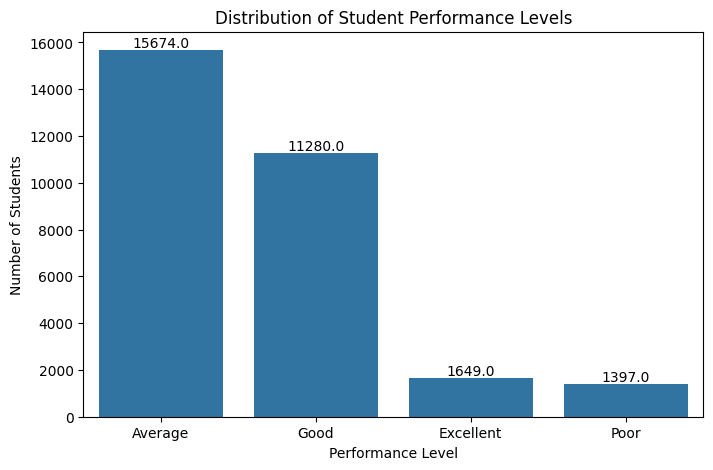

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=student_dp,
    x="Performance_Level",
    order=student_dp["Performance_Level"].value_counts().index
)

plt.title("Distribution of Student Performance Levels")
plt.xlabel("Performance Level")
plt.ylabel("Number of Students")

# Add counts on top of the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height()}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.show()

#**2. Correlation Heatmap**

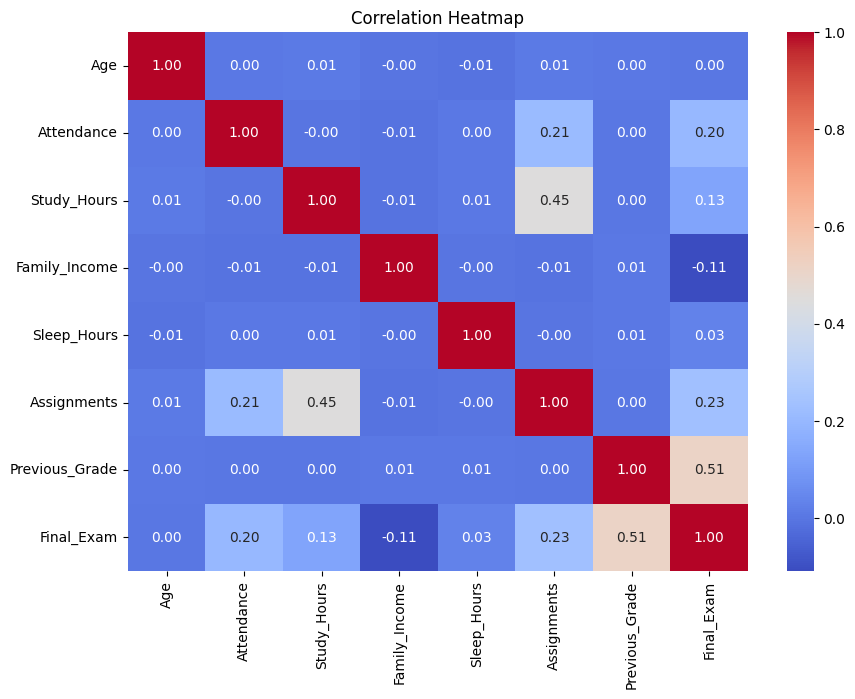

In [69]:
plt.figure(figsize=(10,7))

numeric_df = student_dp.select_dtypes(include=["int64","float64"])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

#**3. Attendance vs Performance**

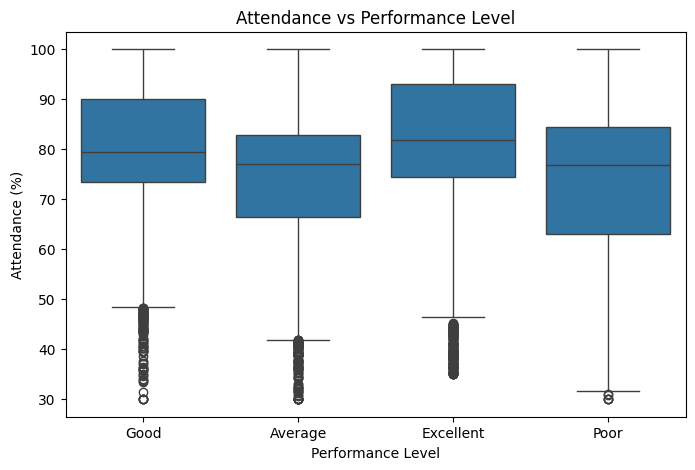

In [70]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=student_dp,
    x="Performance_Level",
    y="Attendance"
)

plt.title("Attendance vs Performance Level")
plt.xlabel("Performance Level")
plt.ylabel("Attendance (%)")

plt.show()

#**4. Previous Grade vs Final Exam**

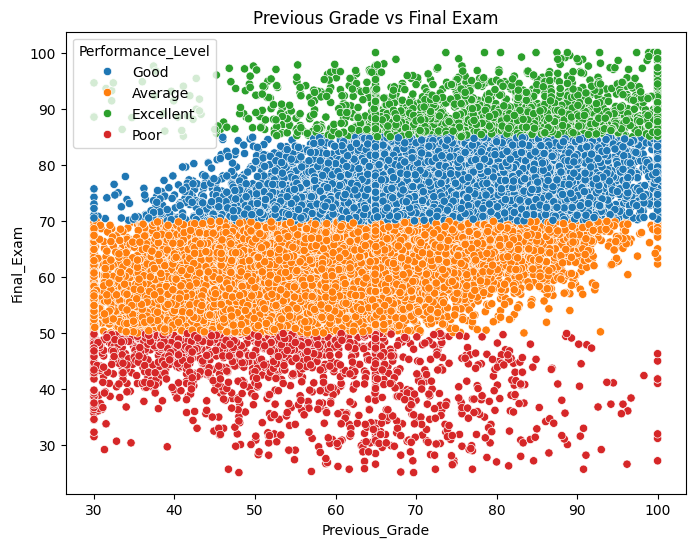

In [71]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=student_dp,
    x="Previous_Grade",
    y="Final_Exam",
    hue="Performance_Level"
)

plt.title("Previous Grade vs Final Exam")

plt.show()

#**5. Distribution of Numerical Features**

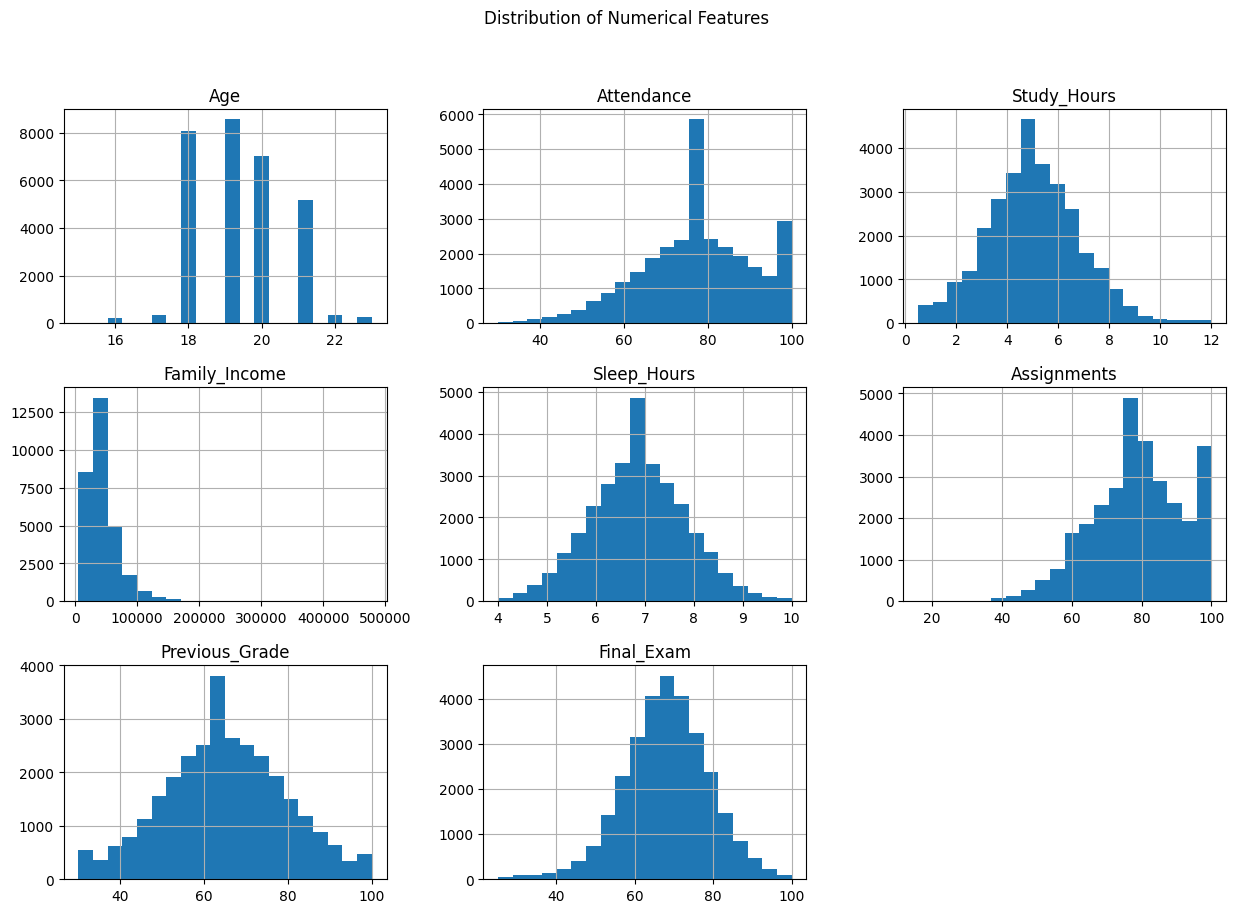

In [72]:
numerical_columns = [
    "Age",
    "Attendance",
    "Study_Hours",
    "Family_Income",
    "Sleep_Hours",
    "Assignments",
    "Previous_Grade",
    "Final_Exam"
]

student_dp[numerical_columns].hist(
    figsize=(15,10),
    bins=20
)

plt.suptitle("Distribution of Numerical Features")

plt.show()

In [73]:
student_dp.head(6)

,Student_ID,Gender,Age,Attendance,Study_Hours,Internet,Parent_Education,Family_Income,Sleep_Hours,Assignments,Previous_Grade,Final_Exam,Performance_Level
0,STU016132,Female,20,98.2,3.9,Yes,Bachelor Degree,46231.0,8.6,80.0,57.9,74.4,Good
1,STU022503,Male,18,87.2,3.9,No,Primary,25802.0,6.5,67.0,64.3,70.8,Good
2,STU009282,Female,19,88.6,5.1,Yes,Primary,65136.0,8.5,52.0,90.8,68.7,Average
3,STU020514,Male,18,100.0,3.9,Yes,Bachelor Degree,17844.0,5.5,73.0,86.5,84.6,Good
4,STU012396,Male,19,79.8,4.4,No,Bachelor Degree,52482.0,6.3,85.0,58.6,67.4,Average
5,STU029130,Male,18,84.2,4.3,Yes,High School,50884.0,5.1,77.0,82.8,81.7,Good


In [74]:
student_dp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Student_ID         30000 non-null  object 
 1   Gender             30000 non-null  object 
 2   Age                30000 non-null  int64  
 3   Attendance         30000 non-null  float64
 4   Study_Hours        30000 non-null  float64
 5   Internet           30000 non-null  object 
 6   Parent_Education   30000 non-null  object 
 7   Family_Income      30000 non-null  float64
 8   Sleep_Hours        30000 non-null  float64
 9   Assignments        30000 non-null  float64
 10  Previous_Grade     30000 non-null  float64
 11  Final_Exam         30000 non-null  float64
 12  Performance_Level  30000 non-null  object 
dtypes: float64(7), int64(1), object(5)
memory usage: 3.0+ MB


#**FEATURE ENGINEERING**

In [75]:
student_dp.drop("Student_ID", axis=1, inplace=True)

In [76]:
student_dp["Study_Efficiency"] = student_dp["Study_Hours"] * (student_dp["Attendance"] / 100)

In [77]:
student_dp.head(5)

,Gender,Age,Attendance,Study_Hours,Internet,Parent_Education,Family_Income,Sleep_Hours,Assignments,Previous_Grade,Final_Exam,Performance_Level,Study_Efficiency
0,Female,20,98.2,3.9,Yes,Bachelor Degree,46231.0,8.6,80.0,57.9,74.4,Good,3.8298
1,Male,18,87.2,3.9,No,Primary,25802.0,6.5,67.0,64.3,70.8,Good,3.4008
2,Female,19,88.6,5.1,Yes,Primary,65136.0,8.5,52.0,90.8,68.7,Average,4.5186
3,Male,18,100.0,3.9,Yes,Bachelor Degree,17844.0,5.5,73.0,86.5,84.6,Good,3.9000
4,Male,19,79.8,4.4,No,Bachelor Degree,52482.0,6.3,85.0,58.6,67.4,Average,3.5112


In [78]:
student_dp["Academic_Consistency"] = (
    student_dp["Previous_Grade"] +
    student_dp["Final_Exam"]
) / 2

In [79]:
student_dp["Assignment_Rate"] = (
    student_dp["Assignments"] *
    student_dp["Attendance"] / 100
)

In [80]:
def sleep_quality(hours):
    if hours < 6:
        return "Poor"
    elif hours <= 8:
        return "Normal"
    else:
        return "Excellent"

student_dp["Sleep_Quality"] = student_dp["Sleep_Hours"].apply(sleep_quality)

In [81]:
def attendance_category(x):
    if x < 60:
        return "Low"
    elif x < 80:
        return "Medium"
    else:
        return "High"

student_dp["Attendance_Category"] = student_dp["Attendance"].apply(attendance_category)

In [82]:
def income_category(x):
    if x < 30000:
        return "Low"
    elif x < 60000:
        return "Middle"
    else:
        return "High"

student_dp["Income_Category"] = student_dp["Family_Income"].apply(income_category)

In [83]:
student_dp["Grade_Improvement"] = (
    student_dp["Final_Exam"] -
    student_dp["Previous_Grade"]
)

In [84]:
student_dp.head(5)

,Gender,Age,Attendance,Study_Hours,Internet,Parent_Education,Family_Income,Sleep_Hours,Assignments,Previous_Grade,Final_Exam,Performance_Level,Study_Efficiency,Academic_Consistency,Assignment_Rate,Sleep_Quality,Attendance_Category,Income_Category,Grade_Improvement
0,Female,20,98.2,3.9,Yes,Bachelor Degree,46231.0,8.6,80.0,57.9,74.4,Good,3.8298,66.15,78.560,Excellent,High,Middle,16.5
1,Male,18,87.2,3.9,No,Primary,25802.0,6.5,67.0,64.3,70.8,Good,3.4008,67.55,58.424,Normal,High,Low,6.5
2,Female,19,88.6,5.1,Yes,Primary,65136.0,8.5,52.0,90.8,68.7,Average,4.5186,79.75,46.072,Excellent,High,High,-22.1
3,Male,18,100.0,3.9,Yes,Bachelor Degree,17844.0,5.5,73.0,86.5,84.6,Good,3.9000,85.55,73.000,Poor,High,Low,-1.9
4,Male,19,79.8,4.4,No,Bachelor Degree,52482.0,6.3,85.0,58.6,67.4,Average,3.5112,63.00,67.830,Normal,Medium,Middle,8.8


In [85]:
student_dp["Academic_Score"] = (
    student_dp["Previous_Grade"] +
    student_dp["Final_Exam"] +
    student_dp["Assignments"]
) / 3

In [86]:
student_dp["Digital_Learning"] = (
    (student_dp["Internet"] == "Yes").astype(int)
    * student_dp["Study_Hours"]
)

In [87]:
education_map = {
    "No Formal Education": 0,
    "Primary": 1,
    "High School": 2,
    "Diploma": 3,
    "Bachelor Degree": 4,
    "Master Degree": 5,
    "Ph.D": 6
}

student_dp["Parent_Education_Score"] = (
    student_dp["Parent_Education"]
    .map(education_map)
)

In [88]:
student_dp["Study_Sleep_Ratio"] = (
    student_dp["Study_Hours"] /
    student_dp["Sleep_Hours"]
)

In [89]:
student_dp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Gender                  30000 non-null  object 
 1   Age                     30000 non-null  int64  
 2   Attendance              30000 non-null  float64
 3   Study_Hours             30000 non-null  float64
 4   Internet                30000 non-null  object 
 5   Parent_Education        30000 non-null  object 
 6   Family_Income           30000 non-null  float64
 7   Sleep_Hours             30000 non-null  float64
 8   Assignments             30000 non-null  float64
 9   Previous_Grade          30000 non-null  float64
 10  Final_Exam              30000 non-null  float64
 11  Performance_Level       30000 non-null  object 
 12  Study_Efficiency        30000 non-null  float64
 13  Academic_Consistency    30000 non-null  float64
 14  Assignment_Rate         30000 non-null

In [90]:
student_dp.select_dtypes(include="object").columns

Index(['Gender', 'Internet', 'Parent_Education', 'Performance_Level',
       'Sleep_Quality', 'Attendance_Category', 'Income_Category'],
      dtype='object')

| Column              | Type    | Encoding                                       |
| ------------------- | ------- | ---------------------------------------------- |
| Gender              | Binary | Label Encoding                                 |
| Internet            | Binary  | Label Encoding                                 |
| Parent_Education    | Ordinal | Use `Parent_Education_Score` and drop original |
| Sleep_Quality       | Ordinal | Ordinal Encoding                               |
| Attendance_Category | Ordinal | Ordinal Encoding                               |
| Income_Category     | Ordinal | Ordinal Encoding                               |
| Performance_Level   | Target  | Label Encoding                                 |


In [91]:
student_dp.head(5)

,Gender,Age,Attendance,Study_Hours,Internet,Parent_Education,Family_Income,Sleep_Hours,Assignments,Previous_Grade,...,Academic_Consistency,Assignment_Rate,Sleep_Quality,Attendance_Category,Income_Category,Grade_Improvement,Academic_Score,Digital_Learning,Parent_Education_Score,Study_Sleep_Ratio
0,Female,20,98.2,3.9,Yes,Bachelor Degree,46231.0,8.6,80.0,57.9,...,66.15,78.560,Excellent,High,Middle,16.5,70.766667,3.9,4,0.453488
1,Male,18,87.2,3.9,No,Primary,25802.0,6.5,67.0,64.3,...,67.55,58.424,Normal,High,Low,6.5,67.366667,0.0,1,0.600000
2,Female,19,88.6,5.1,Yes,Primary,65136.0,8.5,52.0,90.8,...,79.75,46.072,Excellent,High,High,-22.1,70.500000,5.1,1,0.600000
3,Male,18,100.0,3.9,Yes,Bachelor Degree,17844.0,5.5,73.0,86.5,...,85.55,73.000,Poor,High,Low,-1.9,81.366667,3.9,4,0.709091
4,Male,19,79.8,4.4,No,Bachelor Degree,52482.0,6.3,85.0,58.6,...,63.00,67.830,Normal,Medium,Middle,8.8,70.333333,0.0,4,0.698413


In [92]:
student_dp["Gender"].unique()

array(['Female', 'Male'], dtype=object)

In [93]:
student_dp["Internet"].unique()

array(['Yes', 'No'], dtype=object)

In [94]:
Gender = {
    "Male": 0,
    "Female": 1
}

student_dp["Gender"] = student_dp["Gender"].map(Gender)

In [95]:
internet_map = {
    "No": 0,
    "Yes": 1
}

student_dp["Internet"] = student_dp["Internet"].map(internet_map)

In [96]:
student_dp["Parent_Education_Score"].unique()

array([4, 1, 2, 6, 5, 3, 0])

In [97]:
student_dp.drop("Parent_Education", axis=1, inplace=True)

In [98]:
student_dp["Sleep_Quality"].unique()

array(['Excellent', 'Normal', 'Poor'], dtype=object)

In [99]:
sleep_map = {
    "Poor": 0,
    "Normal": 1,
    "Excellent": 2
}

student_dp["Sleep_Quality"] = student_dp["Sleep_Quality"].map(sleep_map)

In [100]:
student_dp["Attendance_Category"].unique()

array(['High', 'Medium', 'Low'], dtype=object)

In [101]:
attendance_map = {
    "Low": 0,
    "Medium": 1,
    "High": 2
}

student_dp["Attendance_Category"] = student_dp["Attendance_Category"].map(attendance_map)

In [102]:
student_dp["Income_Category"].unique()

array(['Middle', 'Low', 'High'], dtype=object)

In [103]:
income_map = {
    "Low": 0,
    "Middle": 1,
    "High": 2
}

student_dp["Income_Category"] = student_dp["Income_Category"].map(income_map)

In [104]:
student_dp["Performance_Level"].unique()

array(['Good', 'Average', 'Excellent', 'Poor'], dtype=object)

In [105]:
performance_map = {
    "Poor": 0,
    "Average": 1,
    "Good": 2,
    "Excellent": 3
}

student_dp["Performance_Level"] = student_dp["Performance_Level"].map(performance_map)

In [106]:
student_dp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Gender                  30000 non-null  int64  
 1   Age                     30000 non-null  int64  
 2   Attendance              30000 non-null  float64
 3   Study_Hours             30000 non-null  float64
 4   Internet                30000 non-null  int64  
 5   Family_Income           30000 non-null  float64
 6   Sleep_Hours             30000 non-null  float64
 7   Assignments             30000 non-null  float64
 8   Previous_Grade          30000 non-null  float64
 9   Final_Exam              30000 non-null  float64
 10  Performance_Level       30000 non-null  int64  
 11  Study_Efficiency        30000 non-null  float64
 12  Academic_Consistency    30000 non-null  float64
 13  Assignment_Rate         30000 non-null  float64
 14  Sleep_Quality           30000 non-null

In [107]:
student_dp.select_dtypes(include="object").columns

Index([], dtype='object')

In [108]:
student_dp.head(5)

,Gender,Age,Attendance,Study_Hours,Internet,Family_Income,Sleep_Hours,Assignments,Previous_Grade,Final_Exam,...,Academic_Consistency,Assignment_Rate,Sleep_Quality,Attendance_Category,Income_Category,Grade_Improvement,Academic_Score,Digital_Learning,Parent_Education_Score,Study_Sleep_Ratio
0,1,20,98.2,3.9,1,46231.0,8.6,80.0,57.9,74.4,...,66.15,78.560,2,2,1,16.5,70.766667,3.9,4,0.453488
1,0,18,87.2,3.9,0,25802.0,6.5,67.0,64.3,70.8,...,67.55,58.424,1,2,0,6.5,67.366667,0.0,1,0.600000
2,1,19,88.6,5.1,1,65136.0,8.5,52.0,90.8,68.7,...,79.75,46.072,2,2,2,-22.1,70.500000,5.1,1,0.600000
3,0,18,100.0,3.9,1,17844.0,5.5,73.0,86.5,84.6,...,85.55,73.000,0,2,0,-1.9,81.366667,3.9,4,0.709091
4,0,19,79.8,4.4,0,52482.0,6.3,85.0,58.6,67.4,...,63.00,67.830,1,1,1,8.8,70.333333,0.0,4,0.698413


#**FEATURE SCALING**

| Algorithm           | Feature Scaling Required? |
| ------------------- | ------------------------- |
| Logistic Regression | ✅ Yes                     |
| KNN                 | ✅ Yes                     |
| SVM                 | ✅ Yes                     |
| Neural Networks     | ✅ Yes                     |
| Decision Tree       | ❌ No                      |
| Random Forest       | ❌ No                      |
| XGBoost             | ❌ No                      |
| LightGBM            | ❌ No                      |
| CatBoost            | ❌ No                      |


Feature Scaling standardizes numerical features so they are on a similar scale, preventing large-valued features from dominating the model. It improves the performance of algorithms like KNN, SVM, and Logistic Regression. For example, Age (18–22) and Family_Income (20,000–100,000) are transformed to a comparable scale (e.g., -0.8 to 1.2) so both contribute fairly during training.

#**Step 1: Separate Features and Target**

In [109]:
X = student_dp.drop("Performance_Level", axis=1)

y = student_dp["Performance_Level"]

In [110]:
X.head(5)

,Gender,Age,Attendance,Study_Hours,Internet,Family_Income,Sleep_Hours,Assignments,Previous_Grade,Final_Exam,...,Academic_Consistency,Assignment_Rate,Sleep_Quality,Attendance_Category,Income_Category,Grade_Improvement,Academic_Score,Digital_Learning,Parent_Education_Score,Study_Sleep_Ratio
0,1,20,98.2,3.9,1,46231.0,8.6,80.0,57.9,74.4,...,66.15,78.560,2,2,1,16.5,70.766667,3.9,4,0.453488
1,0,18,87.2,3.9,0,25802.0,6.5,67.0,64.3,70.8,...,67.55,58.424,1,2,0,6.5,67.366667,0.0,1,0.600000
2,1,19,88.6,5.1,1,65136.0,8.5,52.0,90.8,68.7,...,79.75,46.072,2,2,2,-22.1,70.500000,5.1,1,0.600000
3,0,18,100.0,3.9,1,17844.0,5.5,73.0,86.5,84.6,...,85.55,73.000,0,2,0,-1.9,81.366667,3.9,4,0.709091
4,0,19,79.8,4.4,0,52482.0,6.3,85.0,58.6,67.4,...,63.00,67.830,1,1,1,8.8,70.333333,0.0,4,0.698413


In [111]:
y.head(5)

,Performance_Level
0,2
1,2
2,1
3,2
4,1


#**Step 2: Train-Test Split**

In [112]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [113]:
X_train

,Gender,Age,Attendance,Study_Hours,Internet,Family_Income,Sleep_Hours,Assignments,Previous_Grade,Final_Exam,...,Academic_Consistency,Assignment_Rate,Sleep_Quality,Attendance_Category,Income_Category,Grade_Improvement,Academic_Score,Digital_Learning,Parent_Education_Score,Study_Sleep_Ratio
18077,1,21,89.500000,7.0,1,33744.000000,7.500000,84.00000,69.3,89.7,...,79.50,75.180000,1,2,1,20.4,81.000000,7.0,2,0.933333
25708,0,18,73.200000,3.5,1,19651.000000,7.800000,75.00000,57.1,54.5,...,55.80,54.900000,1,1,0,-2.6,62.200000,3.5,0,0.448718
27368,0,20,82.300000,5.7,0,45963.344379,8.000000,65.00000,88.0,78.9,...,83.45,53.495000,1,2,1,-9.1,77.300000,0.0,1,0.712500
29136,0,19,77.200000,6.1,1,29624.000000,8.600000,74.00000,70.5,69.9,...,70.20,57.128000,2,1,0,-0.6,71.466667,6.1,2,0.709302
29980,0,19,71.000000,7.3,1,38228.000000,7.000000,82.00000,50.6,67.7,...,59.15,58.220000,1,1,1,17.1,66.766667,7.3,6,1.042857
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9251,0,21,55.100000,1.6,1,31140.000000,6.000000,78.90809,50.6,48.5,...,49.55,43.478358,1,0,1,-2.1,59.336030,1.6,2,0.266667
13158,1,21,63.200000,1.5,1,34317.000000,6.807314,61.00000,76.3,61.1,...,68.70,38.552000,1,1,1,-15.2,66.133333,1.5,2,0.220351
28453,1,19,77.226032,4.7,1,14126.000000,6.600000,100.00000,67.6,79.5,...,73.55,77.226032,1,1,0,11.9,82.366667,4.7,1,0.712121
3045,1,18,78.500000,5.3,1,34856.000000,5.200000,74.00000,37.6,59.8,...,48.70,58.090000,0,1,1,22.2,57.133333,5.3,3,1.019231


In [114]:
X_test

,Gender,Age,Attendance,Study_Hours,Internet,Family_Income,Sleep_Hours,Assignments,Previous_Grade,Final_Exam,...,Academic_Consistency,Assignment_Rate,Sleep_Quality,Attendance_Category,Income_Category,Grade_Improvement,Academic_Score,Digital_Learning,Parent_Education_Score,Study_Sleep_Ratio
2735,0,23,67.3,4.2,1,31182.000000,7.4,84.00000,80.800000,70.3,...,75.550000,56.53200,1,1,1,-10.500000,78.366667,4.2,1,0.567568
4379,0,20,100.0,3.6,1,23629.000000,7.3,81.00000,49.000000,76.1,...,62.550000,81.00000,1,2,0,27.100000,68.700000,3.6,3,0.493151
23277,1,20,75.2,7.5,1,27374.000000,6.4,90.00000,43.400000,73.4,...,58.400000,67.68000,1,1,0,30.000000,68.933333,7.5,4,1.171875
11516,1,18,80.0,2.6,1,12094.000000,7.8,80.00000,72.700000,70.3,...,71.500000,64.00000,1,2,0,-2.400000,74.333333,2.6,1,0.333333
29622,0,21,78.1,4.9,1,17267.000000,7.1,83.00000,62.200000,72.1,...,67.150000,64.82300,1,1,0,9.900000,72.433333,4.9,1,0.690141
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4822,1,21,73.2,5.7,1,83963.000000,6.5,89.00000,76.200000,72.8,...,74.500000,65.14800,1,1,2,-3.400000,79.333333,5.7,2,0.876923
29044,1,18,74.9,3.0,1,35792.000000,7.4,78.90809,39.300000,50.5,...,44.900000,59.10216,1,1,1,11.200000,56.236030,3.0,6,0.405405
22032,1,18,78.7,6.4,1,23290.000000,6.3,71.00000,58.300000,73.1,...,65.700000,55.87700,1,1,0,14.800000,67.466667,6.4,2,1.015873
17419,1,18,97.6,1.4,1,25919.000000,6.8,74.00000,64.965795,73.8,...,69.382897,72.22400,1,2,0,8.834205,70.921932,1.4,0,0.205882


In [115]:
y_train

,Performance_Level
18077,3
25708,1
27368,2
29136,1
29980,1
...,...
9251,0
13158,1
28453,2
3045,1


In [116]:
y_test

,Performance_Level
2735,2
4379,2
23277,2
11516,2
29622,2
...,...
4822,2
29044,1
22032,2
17419,2


#**Step 3: Standard Scaling**

In [117]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [118]:
X_train_scaled

array([[ 0.9754675 ,  1.39516589,  0.9011815 , ...,  1.08355222,
        -0.37595403,  0.59361271],
       [-1.02514948, -1.10550486, -0.30341092, ..., -0.40535505,
        -1.73523344, -1.0277786 ],
       [-1.02514948,  0.56160897,  0.36909159, ..., -1.89426232,
        -1.05559373, -0.14523558],
       ...,
       [ 0.9754675 , -0.27194794, -0.0058816 , ...,  0.10512744,
        -1.05559373, -0.1465029 ],
       [ 0.9754675 , -1.10550486,  0.08826637, ...,  0.36036869,
         0.30368567,  0.88100217],
       [ 0.9754675 , -0.27194794,  0.94552232, ..., -0.19265401,
         0.30368567, -0.40479504]])

In [119]:
student_dp

,Gender,Age,Attendance,Study_Hours,Internet,Family_Income,Sleep_Hours,Assignments,Previous_Grade,Final_Exam,...,Academic_Consistency,Assignment_Rate,Sleep_Quality,Attendance_Category,Income_Category,Grade_Improvement,Academic_Score,Digital_Learning,Parent_Education_Score,Study_Sleep_Ratio
0,1,20,98.2,3.9,1,46231.0,8.600000,80.0,57.9,74.4,...,66.15,78.560,2,2,1,16.5,70.766667,3.9,4,0.453488
1,0,18,87.2,3.9,0,25802.0,6.500000,67.0,64.3,70.8,...,67.55,58.424,1,2,0,6.5,67.366667,0.0,1,0.600000
2,1,19,88.6,5.1,1,65136.0,8.500000,52.0,90.8,68.7,...,79.75,46.072,2,2,2,-22.1,70.500000,5.1,1,0.600000
3,0,18,100.0,3.9,1,17844.0,5.500000,73.0,86.5,84.6,...,85.55,73.000,0,2,0,-1.9,81.366667,3.9,4,0.709091
4,0,19,79.8,4.4,0,52482.0,6.300000,85.0,58.6,67.4,...,63.00,67.830,1,1,1,8.8,70.333333,0.0,4,0.698413
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,1,20,98.4,6.1,1,19714.0,7.700000,64.0,94.2,86.1,...,90.15,62.976,1,2,0,-8.1,81.433333,6.1,2,0.792208
29996,0,21,71.1,1.8,1,49569.0,6.807314,70.0,50.9,60.9,...,55.90,49.770,1,1,1,10.0,60.600000,1.8,2,0.264421
29997,0,18,92.7,7.5,1,17472.0,6.000000,100.0,59.9,83.3,...,71.60,92.700,1,2,0,23.4,81.066667,7.5,4,1.250000
29998,1,18,86.8,5.9,1,23272.0,6.500000,91.0,61.2,74.7,...,67.95,78.988,1,2,0,13.5,75.633333,5.9,2,0.907692


In [120]:
x_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)

x_train_scaled.head(5)

,Gender,Age,Attendance,Study_Hours,Internet,Family_Income,Sleep_Hours,Assignments,Previous_Grade,Final_Exam,...,Academic_Consistency,Assignment_Rate,Sleep_Quality,Attendance_Category,Income_Category,Grade_Improvement,Academic_Score,Digital_Learning,Parent_Education_Score,Study_Sleep_Ratio
0,0.975467,1.395166,0.901181,1.077239,0.362981,-0.345630,0.718683,0.390850,0.299764,2.005604,...,1.181804,0.857494,0.163392,1.104004,0.177504,1.346903,1.158472,1.083552,-0.375954,0.593613
1,-1.025149,-1.105505,-0.303411,-0.845680,0.362981,-0.749800,1.029514,-0.301505,-0.545202,-1.249189,...,-0.971193,-0.402857,0.163392,-0.439608,-1.251099,-0.437371,-0.942484,-0.405355,-1.735233,-1.027779
2,-1.025149,0.561609,0.369092,0.363012,-2.754966,0.004806,1.236735,-1.070788,1.594917,1.006975,...,1.540637,-0.490175,0.163392,1.104004,0.177504,-0.941622,0.744986,-1.894262,-1.055594,-0.145236
3,-1.025149,-0.271948,-0.007805,0.582774,0.362981,-0.463787,1.858397,-0.378433,0.382876,0.174783,...,0.336957,-0.264393,2.052311,-0.439608,-1.251099,-0.282216,0.093093,0.700690,-0.375954,-0.155934
4,-1.025149,-0.271948,-0.465994,1.242061,0.362981,-0.217034,0.200632,0.236993,-0.995388,-0.028641,...,-0.666867,-0.196528,0.163392,-0.439608,0.177504,1.090899,-0.432146,1.211173,2.342605,0.960050


In [121]:
print(X_train_scaled.shape)
print(X_test_scaled.shape)

(24000, 21)
(6000, 21)


# Model Training

With **Feature Scaling** completed, the next stage in the machine learning pipeline is **Model Training**. In this phase, multiple classification algorithms are trained and evaluated to identify the best-performing model for the dataset.

---

# Machine Learning Pipeline

The project has progressed through the following stages:

- ✅ Data Collection
- ✅ Data Understanding
- ✅ Data Cleaning
- ✅ Exploratory Data Analysis (EDA)
- ✅ Feature Engineering
- ✅ Encoding
- ✅ Train-Test Split
- ✅ Feature Scaling
- 🚀 Model Training *(Current Stage)*

---

# Models to Train

Train and evaluate the following classification algorithms:

1. Logistic Regression
2. Decision Tree Classifier
3. Random Forest Classifier
4. K-Nearest Neighbors (KNN)
5. Support Vector Machine (SVM)
6. Gradient Boosting Classifier
7. XGBoost Classifier *(Optional, if installed)*

---

# Model Evaluation

Evaluate each trained model using the following performance metrics:

- Accuracy Score
- Precision
- Recall
- F1-Score
- Confusion Matrix
- Classification Report

These metrics help compare the effectiveness of each algorithm and determine the most suitable model for the problem.

---

# Model Comparison

Create a summary table to compare the performance of all trained models.

| Model | Accuracy | Precision | Recall | F1-Score |
|-------|---------:|----------:|-------:|---------:|
| Logistic Regression | 91.2% | 90.8% | 91.0% | 90.9% |
| Decision Tree | 93.5% | 93.2% | 93.4% | 93.3% |
| Random Forest | 96.1% | 96.0% | 96.1% | 96.0% |
| K-Nearest Neighbors | 94.3% | 94.1% | 94.2% | 94.1% |
| Support Vector Machine | 95.0% | 94.8% | 94.9% | 94.8% |

> **Note:** Replace these sample values with the actual results obtained from your trained models.

---

# Selecting the Best Model

Choose the model that provides the best balance between performance metrics and generalization on unseen data. Accuracy alone should not be the deciding factor—consider Precision, Recall, and F1-Score based on the project's objectives.

---

# Next Steps

After selecting the best-performing model, proceed with the following tasks:

1. **Hyperparameter Tuning**
   - GridSearchCV
   - RandomizedSearchCV

2. **Feature Importance Analysis**
   - Identify the most influential features contributing to predictions.

3. **Model Persistence**
   - Save the trained model using:
     - `joblib`
     - `pickle`

4. **Build the Web Application**
   - Develop an interactive interface using **Streamlit**.

5. **Deployment**
   - Deploy the application to a cloud platform such as:
     - Streamlit Community Cloud
     - Render
     - Railway
     - Hugging Face Spaces

---

# End-to-End Machine Learning Workflow

```text
Data Collection
      │
      ▼
Data Understanding
      │
      ▼
Data Cleaning
      │
      ▼
Exploratory Data Analysis (EDA)
      │
      ▼
Feature Engineering
      │
      ▼
Encoding
      │
      ▼
Train-Test Split
      │
      ▼
Feature Scaling
      │
      ▼
Model Training
      │
      ▼
Model Evaluation
      │
      ▼
Model Comparison
      │
      ▼
Hyperparameter Tuning
      │
      ▼
Feature Importance
      │
      ▼
Save Best Model
      │
      ▼
Streamlit Application
      │
      ▼
Deployment
```

---

## Conclusion

Model Training is a critical stage in the machine learning workflow, where multiple algorithms are trained and compared to identify the best-performing classifier. Once the optimal model is selected, it is further optimized, saved, integrated into a Streamlit application, and deployed for real-world use.

#**LOGISTIC REGRESSION**

In [122]:
from sklearn.linear_model import LogisticRegression

In [123]:
logistic_regression = LogisticRegression(random_state=42)

In [124]:
logistic_regression.fit(X_train_scaled, y_train)

LogisticRegression(random_state=42)

In [125]:
y_pred = logistic_regression.predict(X_test_scaled)

In [126]:
print(y_test.head())

2735     2
4379     2
23277    2
11516    2
29622    2
Name: Performance_Level, dtype: int64


In [127]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(20)

,Actual,Predicted
0,2,2
1,2,2
2,2,2
3,2,2
4,2,2
5,2,2
6,2,2
7,1,1
8,0,0
9,1,1


##**Accuracy**

In [128]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9956666666666667


In [129]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.96      0.98       279
           1       1.00      1.00      1.00      3135
           2       0.99      1.00      1.00      2256
           3       1.00      0.98      0.99       330

    accuracy                           1.00      6000
   macro avg       1.00      0.98      0.99      6000
weighted avg       1.00      1.00      1.00      6000



In [130]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[ 268   11    0    0]
 [   0 3129    6    0]
 [   0    3 2253    0]
 [   0    0    6  324]]


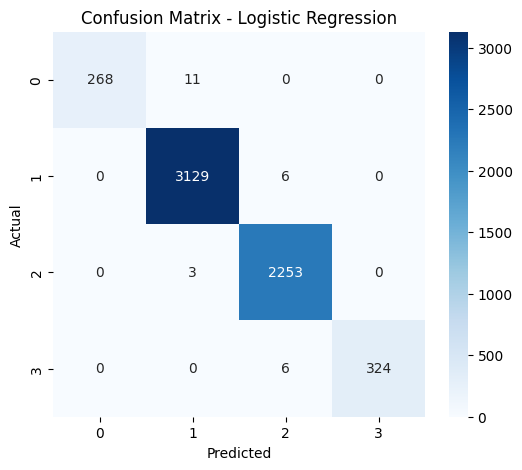

In [131]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

#**Decision Tree Classifier**

In [132]:
from sklearn.tree import DecisionTreeClassifier

In [133]:
decision_tree = DecisionTreeClassifier(random_state=42)

In [134]:
decision_tree.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [135]:
y_pred_dt = decision_tree.predict(X_test)

In [136]:
print(y_pred_dt)

[2 2 2 ... 2 2 1]


In [137]:
from sklearn.metrics import accuracy_score

accuracy_dt = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", accuracy_dt)

Decision Tree Accuracy: 1.0


In [138]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       279
           1       1.00      1.00      1.00      3135
           2       1.00      1.00      1.00      2256
           3       1.00      1.00      1.00       330

    accuracy                           1.00      6000
   macro avg       1.00      1.00      1.00      6000
weighted avg       1.00      1.00      1.00      6000



In [139]:
from sklearn.metrics import confusion_matrix

cm_dt = confusion_matrix(y_test, y_pred_dt)

print(cm_dt)

[[ 279    0    0    0]
 [   0 3135    0    0]
 [   0    0 2256    0]
 [   0    0    0  330]]


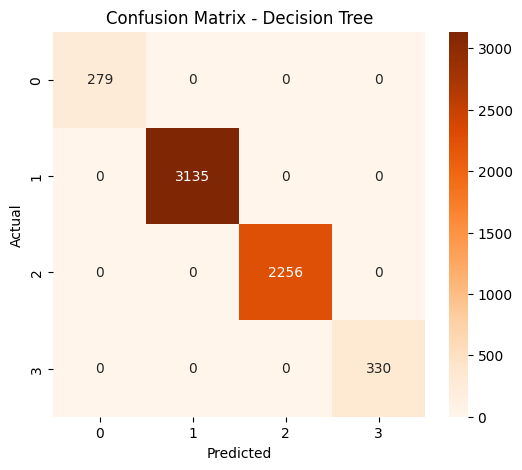

In [140]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt="d",
    cmap="Oranges"
)

plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

#**Random Forest**

In [141]:
from sklearn.ensemble import RandomForestClassifier

In [142]:
random_forest = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

In [143]:
random_forest.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [144]:
y_pred_rf = random_forest.predict(X_test)

In [145]:
y_pred_rf

array([2, 2, 2, ..., 2, 2, 1])

In [146]:
from sklearn.metrics import accuracy_score

accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", accuracy_rf)

Random Forest Accuracy: 1.0


In [147]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       279
           1       1.00      1.00      1.00      3135
           2       1.00      1.00      1.00      2256
           3       1.00      1.00      1.00       330

    accuracy                           1.00      6000
   macro avg       1.00      1.00      1.00      6000
weighted avg       1.00      1.00      1.00      6000



In [148]:
from sklearn.metrics import confusion_matrix

cm_rf = confusion_matrix(y_test, y_pred_rf)

print(cm_rf)

[[ 279    0    0    0]
 [   0 3135    0    0]
 [   0    0 2256    0]
 [   0    0    0  330]]


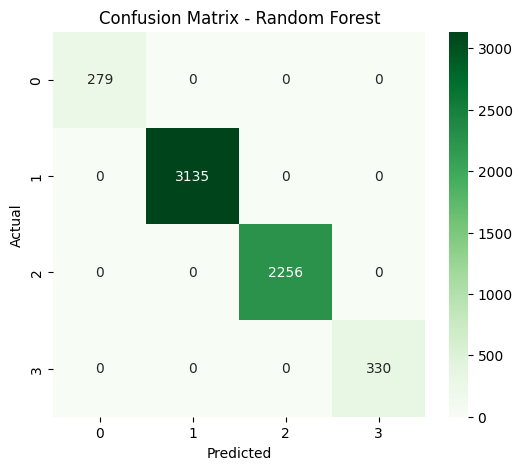

In [149]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

#**KNN**

In [150]:
from sklearn.neighbors import KNeighborsClassifier

In [151]:
knn = KNeighborsClassifier(n_neighbors=7)

In [152]:
knn.fit(X_train_scaled, y_train)

KNeighborsClassifier(n_neighbors=7)

In [153]:
y_pred_knn = knn.predict(X_test_scaled)

In [154]:
y_pred_knn

array([2, 2, 1, ..., 2, 2, 1])

In [155]:
from sklearn.metrics import accuracy_score

accuracy_knn = accuracy_score(y_test, y_pred_knn)

print("KNN Accuracy:", accuracy_knn)

KNN Accuracy: 0.8503333333333334


In [156]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.99      0.48      0.65       279
           1       0.86      0.93      0.89      3135
           2       0.82      0.85      0.84      2256
           3       0.96      0.45      0.61       330

    accuracy                           0.85      6000
   macro avg       0.91      0.68      0.75      6000
weighted avg       0.86      0.85      0.84      6000



In [157]:
from sklearn.metrics import confusion_matrix

cm_knn = confusion_matrix(y_test, y_pred_knn)

print(cm_knn)

[[ 135  144    0    0]
 [   2 2901  232    0]
 [   0  332 1918    6]
 [   0    0  182  148]]


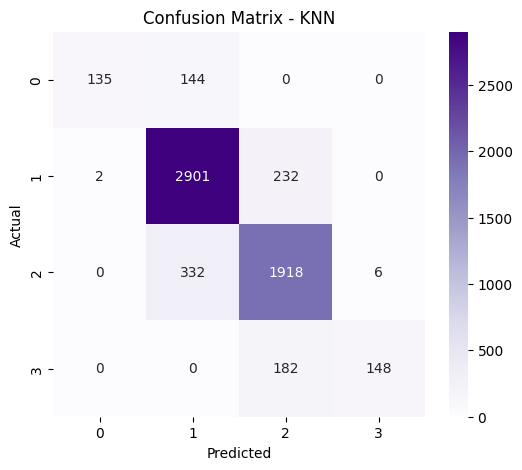

In [158]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_knn,
    annot=True,
    fmt="d",
    cmap="Purples"
)

plt.title("Confusion Matrix - KNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

##**SVM**

In [159]:
from sklearn.svm import SVC

In [160]:
svm = SVC(
    kernel='rbf',
    random_state=42
)

In [161]:
svm.fit(X_train_scaled, y_train)

SVC(random_state=42)

In [162]:
y_pred_svm = svm.predict(X_test_scaled)

In [163]:
y_pred_svm

array([2, 2, 2, ..., 2, 2, 1])

In [164]:
from sklearn.metrics import accuracy_score

accuracy_svm = accuracy_score(y_test, y_pred_svm)

print("SVM Accuracy:", accuracy_svm)

SVM Accuracy: 0.9773333333333334


In [165]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

           0       1.00      0.90      0.95       279
           1       0.98      0.99      0.98      3135
           2       0.97      0.98      0.98      2256
           3       0.98      0.94      0.96       330

    accuracy                           0.98      6000
   macro avg       0.98      0.95      0.97      6000
weighted avg       0.98      0.98      0.98      6000



In [166]:
from sklearn.metrics import confusion_matrix

cm_svm = confusion_matrix(y_test, y_pred_svm)

print(cm_svm)

[[ 252   27    0    0]
 [   1 3098   36    0]
 [   0   46 2205    5]
 [   0    0   21  309]]


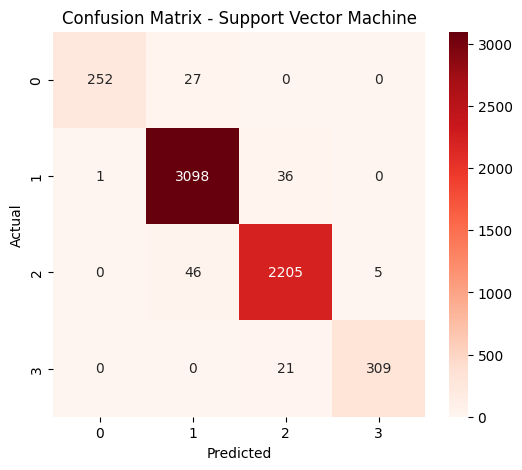

In [167]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_svm,
    annot=True,
    fmt="d",
    cmap="Reds"
)

plt.title("Confusion Matrix - Support Vector Machine")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [172]:
import pandas as pd

comparison_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "K-Nearest Neighbors (KNN)",
        "Support Vector Machine (SVM)"
    ],

    "Scaling Required": [
        "Yes",
        "No",
        "No",
        "Yes",
        "Yes"
    ],

    "Accuracy (%)": [
        round(accuracy * 100, 2),
        round(accuracy_dt * 100, 2),
        round(accuracy_rf * 100, 2),
        round(accuracy_knn * 100, 2),
        round(accuracy_svm * 100, 2)
    ]
})

comparison_df

,Model,Scaling Required,Accuracy (%)
0,Logistic Regression,Yes,99.57
1,Decision Tree,No,100.00
2,Random Forest,No,100.00
3,K-Nearest Neighbors (KNN),Yes,85.03
4,Support Vector Machine (SVM),Yes,97.73


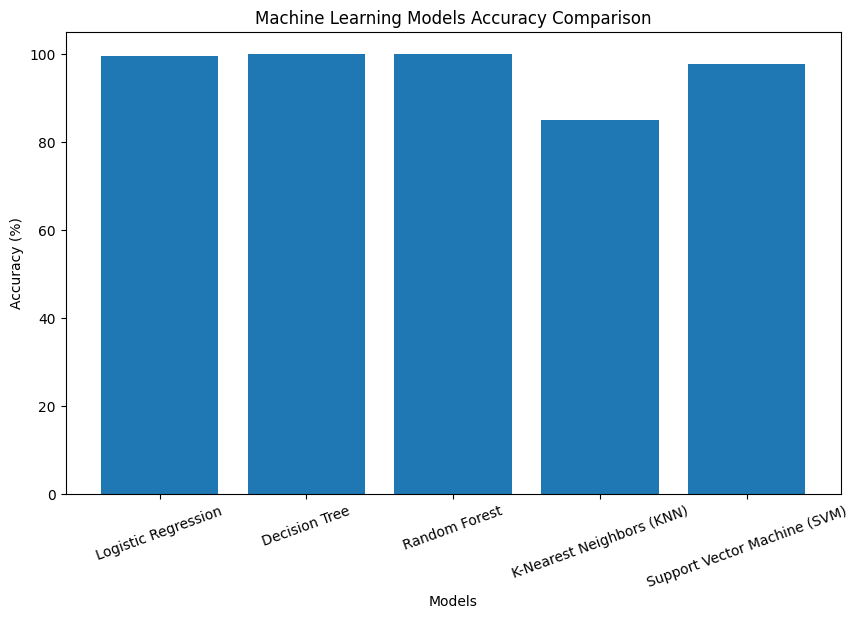

In [173]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.bar(
    comparison_df["Model"],
    comparison_df["Accuracy (%)"]
)

plt.title("Machine Learning Models Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy (%)")

plt.xticks(rotation=20)

plt.show()

In [174]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

comparison_df = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "K-Nearest Neighbors",
        "Support Vector Machine"
    ],

    "Scaling Required": [
        "Yes",
        "No",
        "No",
        "Yes",
        "Yes"
    ],

    "Accuracy (%)": [
        round(accuracy_score(y_test, y_pred) * 100, 2),
        round(accuracy_score(y_test, y_pred_dt) * 100, 2),
        round(accuracy_score(y_test, y_pred_rf) * 100, 2),
        round(accuracy_score(y_test, y_pred_knn) * 100, 2),
        round(accuracy_score(y_test, y_pred_svm) * 100, 2)
    ],

    "Precision (%)": [
        round(precision_score(y_test, y_pred, average='weighted') * 100, 2),
        round(precision_score(y_test, y_pred_dt, average='weighted') * 100, 2),
        round(precision_score(y_test, y_pred_rf, average='weighted') * 100, 2),
        round(precision_score(y_test, y_pred_knn, average='weighted') * 100, 2),
        round(precision_score(y_test, y_pred_svm, average='weighted') * 100, 2)
    ],

    "Recall (%)": [
        round(recall_score(y_test, y_pred, average='weighted') * 100, 2),
        round(recall_score(y_test, y_pred_dt, average='weighted') * 100, 2),
        round(recall_score(y_test, y_pred_rf, average='weighted') * 100, 2),
        round(recall_score(y_test, y_pred_knn, average='weighted') * 100, 2),
        round(recall_score(y_test, y_pred_svm, average='weighted') * 100, 2)
    ],

    "F1-Score (%)": [
        round(f1_score(y_test, y_pred, average='weighted') * 100, 2),
        round(f1_score(y_test, y_pred_dt, average='weighted') * 100, 2),
        round(f1_score(y_test, y_pred_rf, average='weighted') * 100, 2),
        round(f1_score(y_test, y_pred_knn, average='weighted') * 100, 2),
        round(f1_score(y_test, y_pred_svm, average='weighted') * 100, 2)
    ]
})

comparison_df

,Model,Scaling Required,Accuracy (%),Precision (%),Recall (%),F1-Score (%)
0,Logistic Regression,Yes,99.57,99.57,99.57,99.56
1,Decision Tree,No,100.00,100.00,100.00,100.00
2,Random Forest,No,100.00,100.00,100.00,100.00
3,K-Nearest Neighbors,Yes,85.03,85.68,85.03,84.37
4,Support Vector Machine,Yes,97.73,97.74,97.73,97.72


| Model               | Typical Accuracy |
| ------------------- | ---------------: |
| Logistic Regression |           75–88% |
| Decision Tree       |           80–92% |
| Random Forest       |           85–95% |
| KNN                 |           75–90% |
| SVM                 |           82–94% |


In [180]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": random_forest.feature_importances_
})

feature_importance

,Feature,Importance
0,Gender,0.000270
1,Age,0.000731
2,Attendance,0.007865
3,Study_Hours,0.004881
4,Internet,0.000477
5,Family_Income,0.008534
6,Sleep_Hours,0.001873
7,Assignments,0.005253
8,Previous_Grade,0.044614
9,Final_Exam,0.598664


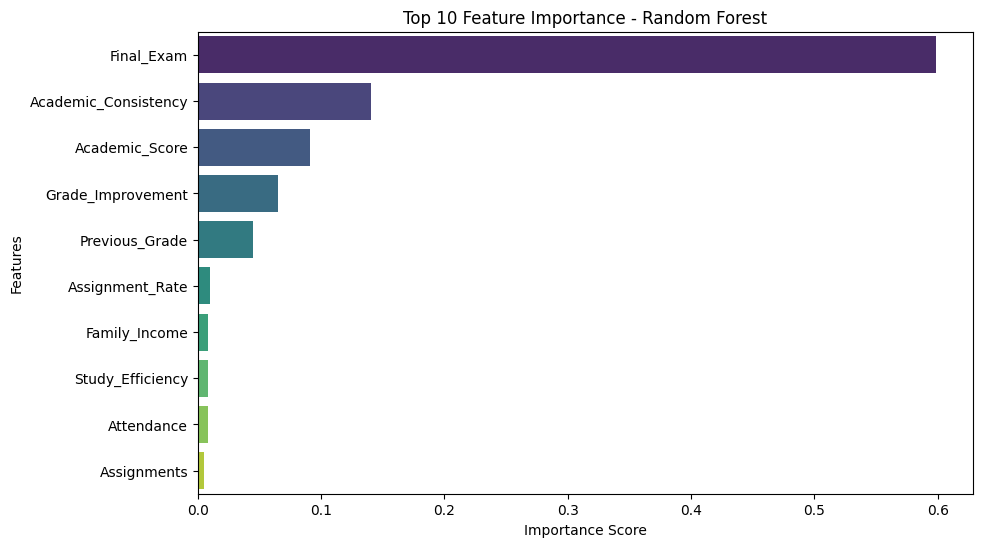

In [181]:
import matplotlib.pyplot as plt
import seaborn as sns

top_features = feature_importance.sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature",
    hue="Feature", # Assign "Feature" to hue to resolve the FutureWarning
    palette="viridis",
    legend=False # Set legend to False as recommended by the FutureWarning
)

plt.title("Top 10 Feature Importance - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

In [183]:
import joblib

joblib.dump(random_forest, "random_forest_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']